In [13]:
import os
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

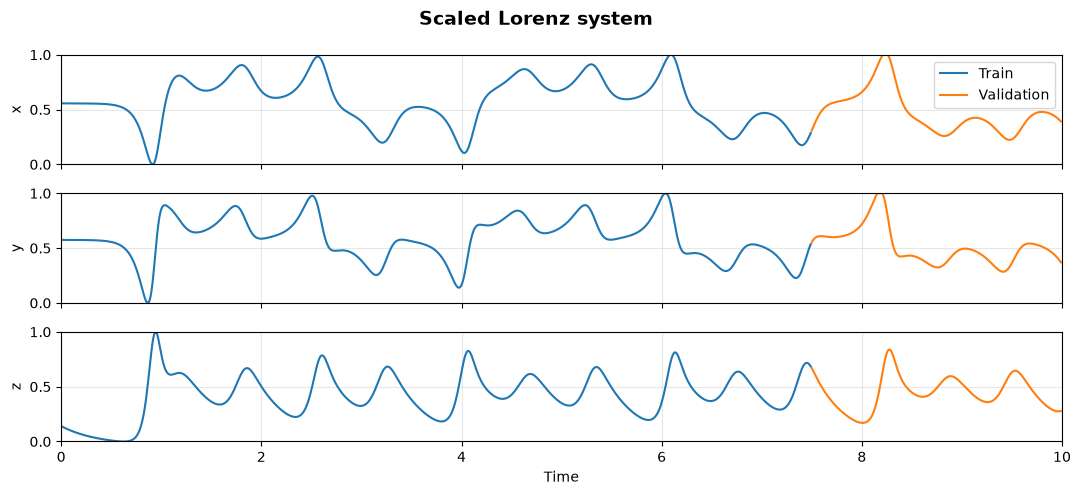

In [14]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# Hybrid VQC with classical pre/post processing

In this section, we first use a classical encoder to reduce the dimensionality of the input data. The encoded features are then processed by the same strongly entangling layers VQC used in the previous sections. Finally, a classical decoder maps the resulting features back to the forecasting space. Both the encoder and decoder use RELU activation between their layers and their mappings are given by:

$$
\phi_{enc}  :\mathbb{R}^{C\times T} \rightarrow \mathbb{R}^{2n} \rightarrow \mathbb{R}^n
$$
$$
\phi_{dec}  :\mathbb{R}^n \rightarrow \mathbb{R}^{2n} \rightarrow  \mathbb{R}^{C\times S}
$$

One particularity of this model is that the number of qubits is a free hyperparameter. Again, the architecture  supports forecasting horizons $S>1$ by  adjusting the output dimension of the final layer.

In [15]:
# Params
batch_size = 128 
n_chanels = 3
window_size = 5
batch_size = 128
horizon = 1
nreps = 24
nqubits = 8 # In this model the number of qubits is a free hyperparameter
weights = {"theta": (3 * nqubits * nreps,)} # Strongly entangling layers

# Training hyperparameters
epochs = 50
lr = 5e-4

In [16]:
dev = qml.device("lightning.qubit", wires=nqubits)

def enc_cod_VQC(inputs, theta):
    angle_encoding(nqubits, inputs)
    VQC_strong(nqubits, theta, nreps)
    output = []
    for i in range(nqubits):
        output.append(qml.expval(qml.Z(i)))
    return output

qnode_enc_cod_VQC = qml.QNode(
    func=enc_cod_VQC,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

class enc_VQC_dec_model(nn.Module):
    def __init__(self, nqubits, n_chanels, window, horizon):
        super().__init__()

        self.enc = nn.Sequential(
            nn.Linear(n_chanels* window, 2*nqubits),   
            nn.ReLU(),
            nn.Linear(2*nqubits, nqubits)     
        )
        self.qlayer = qml.qnn.TorchLayer(qnode_enc_cod_VQC, weights)
                
        self.dec = nn.Sequential(
            nn.Linear(nqubits, 2*nqubits),
            nn.ReLU(),
            nn.Linear(2*nqubits, n_chanels*horizon)  
        )
    
    def forward(self, x):
        # x: (batch, 5, 3)
        x = x.reshape(x.shape[0], -1) # (batch, 15)
        x = self.enc(x)
        x = self.qlayer(x)
        x = self.dec(x)
        return x

# Short forecasting

In [17]:
# Create the sequences
horizon_short = 1

x_tr_short, hor_tr_short = create_sequences(train_scaled, window_size, horizon_short)
x_val_short, hor_val_short = create_sequences(val_scaled, window_size, horizon_short)

x_tr_short = torch.from_numpy(x_tr_short).double()
hor_tr_short = torch.from_numpy(hor_tr_short).double()

x_val_short = torch.from_numpy(x_val_short).double()
hor_val_short = torch.from_numpy(hor_val_short).double()

tr_dataset_short = TensorDataset(x_tr_short, hor_tr_short)
tr_loader_short = DataLoader(tr_dataset_short, batch_size=batch_size, shuffle=False)

In [18]:
# reset_seeds(SEED)

# # Create the model
# model_enc_VQC_dec_model_short = enc_VQC_dec_model(
#     nqubits,
#     n_chanels,
#     window_size,
#     horizon_short
# ).double()

# # Define optimizer and loss function
# opt_short = torch.optim.Adam(params=model_enc_VQC_dec_model_short.parameters(), lr=lr)
# loss_fn = nn.MSELoss()

# # Save the best model
# best_state_short = None
# best_val_loss_short = float("inf")

# history_short = {"Loss": [], "Val loss": []}

# print(30 * "#")
# print("Starting training")
# print(30 * "#")

# for epoch in range(epochs):

#     #Training
#     model_enc_VQC_dec_model_short.train()
#     epoch_loss = 0
#     for xb, yb in tr_loader_short:
#         opt_short.zero_grad()
#         pred = model_enc_VQC_dec_model_short(xb)
#         target = yb.reshape(yb.shape[0], -1)
#         loss = loss_fn(pred, target)    
#         loss.backward()
#         opt_short.step()
#         epoch_loss += loss.item()
    
#     # Store average loss for this epoch
#     epoch_loss /= len(tr_loader_short)
#     history_short["Loss"].append(epoch_loss)

#     # Evaluation
#     model_enc_VQC_dec_model_short.eval()
#     with torch.no_grad():
#         val_pred = model_enc_VQC_dec_model_short(x_val_short)
#         val_target = hor_val_short.reshape(hor_val_short.shape[0], -1)
#         val_loss = loss_fn(val_pred, val_target).item()

#     # Store val loss
#     history_short["Val loss"].append(val_loss)

#     # Save best model
#     if val_loss < best_val_loss_short:
#         best_val_loss_short = val_loss
#         best_state_short = {
#             name: params.detach().clone()
#             for name, params in model_enc_VQC_dec_model_short.state_dict().items()
#         }

#     # Print training progress every 5 epochs
#     if epoch == 0 or (epoch + 1) % 5 == 0:
#         print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


# if best_state_short is not None:
#     model_enc_VQC_dec_model_short.load_state_dict(best_state_short)

In [19]:
# # Save the model
# os.makedirs("../models_states", exist_ok=True)

# checkpoint = {
#     "enc_VQC_dec_short": model_enc_VQC_dec_model_short.state_dict(),
#     "history": history_short
# }
# torch.save(checkpoint, "../models_states/enc_VQC_dec_short.pt")

In [20]:
# Load the model
checkpoint = torch.load(
    "../models_states/enc_VQC_dec_short.pt",
    map_location="cpu"
)

history_short = checkpoint["history"]

model_enc_VQC_dec_model_short = enc_VQC_dec_model(
    nqubits,
    n_chanels,
    window_size,
    horizon_short
).double()

model_enc_VQC_dec_model_short.load_state_dict(checkpoint["enc_VQC_dec_short"])

<All keys matched successfully>

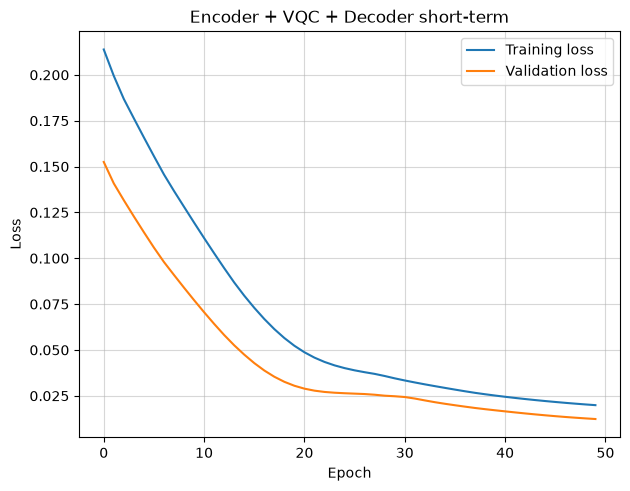

In [21]:
plot_loss(history_short, "Encoder + VQC + Decoder short-term")

In [22]:
# Evaluation mode
model_enc_VQC_dec_model_short.eval()

with torch.no_grad():
    pred_short = model_enc_VQC_dec_model_short(x_val_short)

pred_short_3d = pred_short.reshape(pred_short.shape[0], horizon_short, n_chanels) # (batch, 5, 3)
target_short_3d = hor_val_short

# =====================
# RMSE
# =====================

squared_error = (pred_short_3d - target_short_3d) ** 2
mean_rmse_list_short = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_short = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_short_3d - target_short_3d)
mean_mae_list_short = abs_error.mean(dim=(1, 2))
mean_mae_short = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_short_3d - pred_short_3d) / (target_short_3d + eps))
mean_mape_list_short = percentage_error.mean(dim=(1, 2))
mean_mape_short = percentage_error.mean()

print(f"Global RMSE short forecasting: {mean_rmse_short:.4f}")
print(f"Global MAE short forecasting: {mean_mae_short:.4f}")
print(f"Global MAPE short forecasting: {mean_mape_short:.4f}")

Global RMSE short forecasting: 0.1111
Global MAE short forecasting: 0.0861
Global MAPE short forecasting: 0.2105


In [23]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "Enc-VQC-Dec",
        "MAPE": mean_mape_short,
        "MAE": mean_mae_short,
        "RMSE": mean_rmse_short,
    },
)

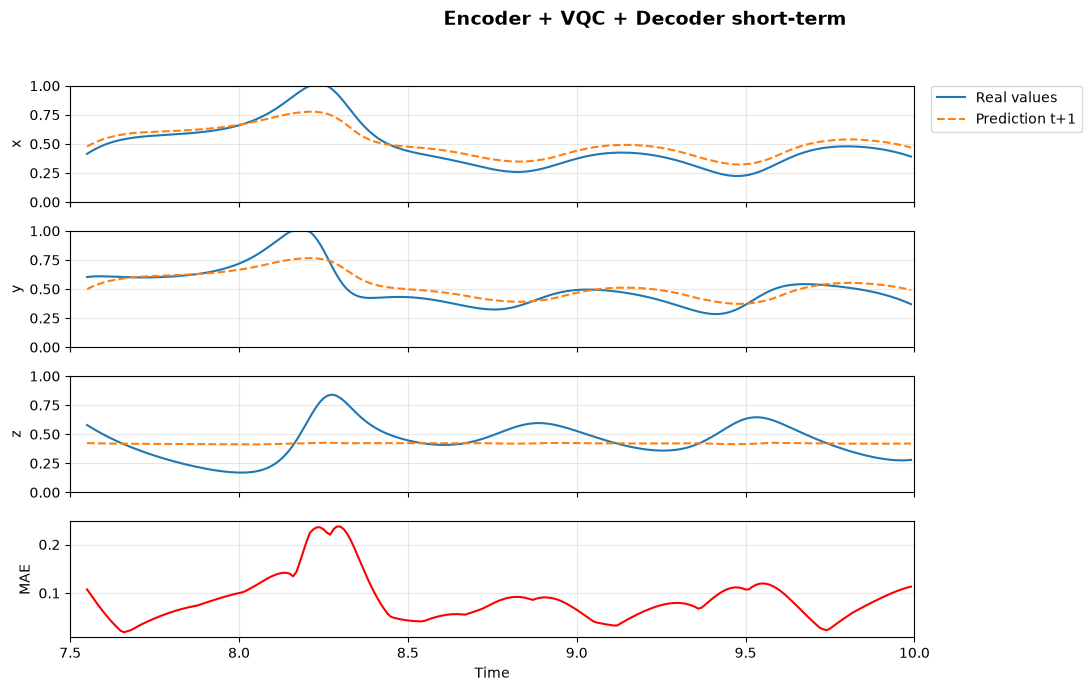

In [24]:
pred_x_short = pred_short_3d[:, :, 0]
pred_y_short = pred_short_3d[:, :, 1]
pred_z_short = pred_short_3d[:, :, 2]

plot_preds_and_error(
    pred_x_short,
    pred_y_short,
    pred_z_short,
    mean_mae_list_short,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_short,
    horizon_step=1,
    title="Encoder + VQC + Decoder short-term"
)

# Long forecasting

In [25]:
# Create the sequences
horizon_long = 5

x_tr_long, hor_tr_long = create_sequences(train_scaled, window_size, horizon_long)
x_val_long, hor_val_long = create_sequences(val_scaled, window_size, horizon_long)

x_tr_long = torch.from_numpy(x_tr_long).double()
hor_tr_long = torch.from_numpy(hor_tr_long).double()

x_val_long = torch.from_numpy(x_val_long).double()
hor_val_long = torch.from_numpy(hor_val_long).double()

tr_dataset_long = TensorDataset(x_tr_long, hor_tr_long)
tr_loader_long = DataLoader(tr_dataset_long, batch_size=batch_size, shuffle=False)

In [26]:
reset_seeds(SEED)

# Create the model
model_enc_VQC_dec_model_long = enc_VQC_dec_model(
    nqubits,
    n_chanels,
    window_size,
    horizon_long
).double()

# Define optimizer and loss function
opt_long = torch.optim.Adam(params=model_enc_VQC_dec_model_long.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state_long = None
best_val_loss_long = float("inf")

history_long = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_enc_VQC_dec_model_long.train()
    epoch_loss = 0
    for xb, yb in tr_loader_long:
        opt_long.zero_grad()
        pred = model_enc_VQC_dec_model_long(xb) # shape: (batch, 15)
        target = yb.reshape(yb.shape[0], -1) # yb shape: (batch, 5, 3)
        loss = loss_fn(pred, target)
        loss.backward()
        opt_long.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_long)
    history_long["Loss"].append(epoch_loss)

    # Evaluation
    model_enc_VQC_dec_model_long.eval()
    with torch.no_grad():
        val_pred = model_enc_VQC_dec_model_long(x_val_long)
        val_target = hor_val_long.reshape(hor_val_long.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history_long["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss_long:
        best_val_loss_long = val_loss
        best_state_long = {
            name: params.detach().clone()
            for name, params in model_enc_VQC_dec_model_long.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state_long is not None:
    model_enc_VQC_dec_model_long.load_state_dict(best_state_long)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.3207 | Validation loss: 0.2602
Epoch: 5 | Loss: 0.2780 | Validation loss: 0.2227
Epoch: 10 | Loss: 0.2224 | Validation loss: 0.1736
Epoch: 15 | Loss: 0.1637 | Validation loss: 0.1242
Epoch: 20 | Loss: 0.1120 | Validation loss: 0.0836
Epoch: 25 | Loss: 0.0735 | Validation loss: 0.0559
Epoch: 30 | Loss: 0.0509 | Validation loss: 0.0406
Epoch: 35 | Loss: 0.0390 | Validation loss: 0.0320
Epoch: 40 | Loss: 0.0323 | Validation loss: 0.0267
Epoch: 45 | Loss: 0.0281 | Validation loss: 0.0234
Epoch: 50 | Loss: 0.0252 | Validation loss: 0.0211


In [27]:
# Save the model
os.makedirs("../models_states", exist_ok=True)

checkpoint = {
    "enc_VQC_dec_long": model_enc_VQC_dec_model_long.state_dict(),
    "history": history_long
}
torch.save(checkpoint, "../models_states/enc_VQC_dec_long.pt")

In [28]:
# # Load the model
# checkpoint = torch.load(
#     "../models_states/enc_VQC_dec_long.pt",
#     map_location="cpu"
# )

# history_long = checkpoint["history"]

# model_enc_VQC_dec_model_long = enc_VQC_dec_model(
#     nqubits,
#     n_chanels,
#     window_size,
#     horizon_long
# ).double()

# model_enc_VQC_dec_model_long.load_state_dict(checkpoint["enc_VQC_dec_long"])

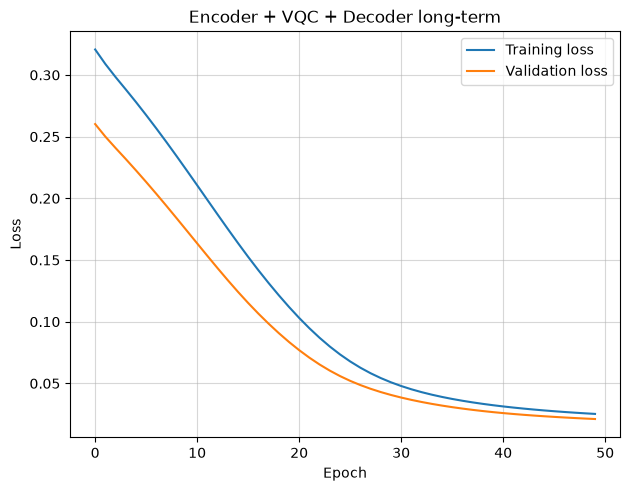

In [29]:
plot_loss(history_long, "Encoder + VQC + Decoder long-term")

In [30]:
# Evaluation mode
model_enc_VQC_dec_model_long.eval()

with torch.no_grad():
    pred_long = model_enc_VQC_dec_model_long(x_val_long)

pred_long_3d = pred_long.reshape(pred_long.shape[0], horizon_long, n_chanels)
target_long_3d = hor_val_long

# =====================
# RMSE
# =====================

squared_error = (pred_long_3d - target_long_3d) ** 2
mean_rmse_list_long = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_long = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_long_3d - target_long_3d)
mean_mae_list_long = abs_error.mean(dim=(1, 2))
mean_mae_long = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_long_3d - pred_long_3d) / (target_long_3d + eps))
mean_mape_list_long = percentage_error.mean(dim=(1, 2))
mean_mape_long = percentage_error.mean()

# =====================
# MAE in t+5 (for the plot)
# =====================

h = 4  # t+5

abs_error_t5 = torch.abs(pred_long_3d[:, h, :] - target_long_3d[:, h, :])
mean_mae_t5_list = abs_error_t5.mean(dim=1)

print(f"Global RMSE long forecasting: {mean_rmse_long:.4f}")
print(f"Global MAE long forecasting: {mean_mae_long:.4f}")
print(f"Global MAPE long forecasting: {mean_mape_long:.4f}")

Global RMSE long forecasting: 0.1453
Global MAE long forecasting: 0.1171
Global MAPE long forecasting: 0.2861


In [31]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "long-term",
        "model": "Enc-VQC-Dec",
        "MAPE": mean_mape_long,
        "MAE": mean_mae_long,
        "RMSE": mean_rmse_long,
    },
)

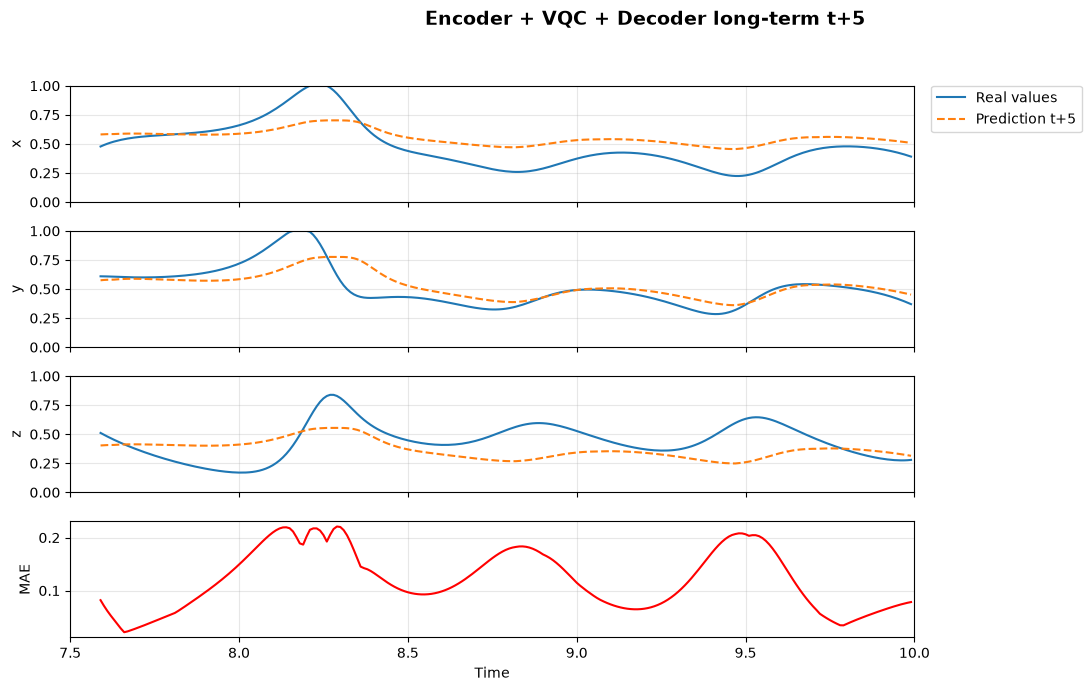

In [32]:
pred_x_long = pred_long_3d[:, :, 0]
pred_y_long = pred_long_3d[:, :, 1]
pred_z_long = pred_long_3d[:, :, 2]

plot_preds_and_error(
    pred_x_long,
    pred_y_long,
    pred_z_long,
    mean_mae_t5_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_long,
    horizon_step=5,
    title="Encoder + VQC + Decoder long-term t+5"
)